### Loading _Breast Cancer Wisconsin (Diagnostic)_ dataset

Additional Information

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.  They describe characteristics of the cell nuclei present in the image. A few of the images can be found at http://www.cs.wisc.edu/~street/images/

Separating plane described above was obtained using Multisurface Method-Tree (MSM-T) [K. P. Bennett, "Decision Tree Construction Via Linear Programming." Proceedings of the 4th Midwest Artificial Intelligence and Cognitive Science Society, pp. 97-101, 1992], a classification method which uses linear programming to construct a decision tree.  Relevant features were selected using an exhaustive search in the space of 1-4 features and 1-3 separating planes.

The actual linear program used to obtain the separating plane in the 3-dimensional space is that described in: [K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server:
ftp ftp.cs.wisc.edu
cd math-prog/cpo-dataset/machine-learn/WDBC/

In [252]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
import pickle
import matplotlib.pyplot as plt

In [253]:
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
X = X[X.columns.to_series().sample(10, random_state=42)]
Y = breast_cancer_wisconsin_diagnostic.data.targets


In [254]:
Y.replace({'M':1,'B':0}, inplace=True)

C:\Users\Emilien JEMELEN\AppData\Local\Temp\ipykernel_6292\2394348624.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y.replace({'M':1,'B':0}, inplace=True)
C:\Users\Emilien JEMELEN\AppData\Local\Temp\ipykernel_6292\2394348624.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y.replace({'M':1,'B':0}, inplace=True)


### Training logistic regression classifier $f$

In [255]:
# split: train (66%) and test (rest)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.6, random_state=42, stratify=Y)

In [256]:
model = LogisticRegression(random_state=42, max_iter=100)
model.fit(X_train, Y_train)

c:\Users\Emilien JEMELEN\Documents\SGR\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [257]:
# On test set after model selection
test_pred = model.predict(X_test)
print(classification_report(Y_test, test_pred))
print('Test Accuracy:', accuracy_score(Y_test, test_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94       215
           1       0.99      0.80      0.88       127

    accuracy                           0.92       342
   macro avg       0.94      0.90      0.91       342
weighted avg       0.93      0.92      0.92       342

Test Accuracy: 0.9210526315789473


### Retrieving $\kappa_f$ confidence function

In [258]:
y_true = Y_test.Diagnosis
y_pred = test_pred
kappa = model.predict_proba(X_test).max(axis=1)

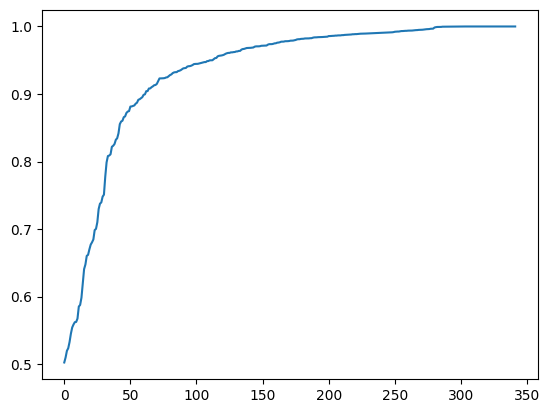

In [259]:
plt.plot(sorted(kappa))

In [260]:
sgr_df = pd.DataFrame({'y_true': y_true,
              'y_pred': y_pred,
              'kappa': kappa}).sort_values('kappa')
sgr_df

,y_true,y_pred,kappa
184,1,1,0.502458
421,0,1,0.509838
214,1,1,0.519748
263,1,0,0.523555
255,1,0,0.532768
...,...,...,...
212,1,1,1.000000
180,1,1,1.000000
503,1,1,1.000000
352,1,1,1.000000


In [261]:
pickle.dump(sgr_df, open('sgr_set_log_reg','wb'))

### Training SVM classifier (linear kernel)